# Project 6 — Weekly Radar: Data Cleaning and Preprocessing

This notebook prepares the uploaded `Performance.xlsx` file for **Project 6: Weekly Radar**.

## What this notebook does
1. Loads the spreadsheet safely.
2. Inspects the structure and checks the columns.
3. Keeps **weekly** rows only and removes the **daily** rows.
4. Keeps **locality** rows for the main workflow and excludes **country** rows from the main anomaly table.
5. Explains **why** that filtering choice makes sense for Project 6.
6. Checks repeated locality rows and exact duplicate rows before aggregation.
7. Builds two cleaned datasets:
   - **weekly_locality_only.csv** → weekly rows at locality level
   - **weekly_region_carrier_tech.csv** → weekly rows aggregated to `region × carrier × technology × week`
8. Uses `sample_count` weighting, including a documented median proxy, because raw speed-test observations are not available.

## Important note about `country`
For the **main model**, excluding `place_type == "country"` is the best choice, because the project asks us to compare:
- carriers **within regions**
- regions **against each other**
- rank the **13 regions**

The Egypt-level aggregate is useful as a **reference benchmark**, but it should not be mixed with locality/region rows in the main anomaly table because it is not a peer observation.

So the best practical decision is:

- **Keep locality rows** as the source of truth for analysis.
- **Remove country rows from the main analysis table.**
- Optionally keep country rows in a separate benchmark table.

That matches the project wording about cross-sectional comparisons and region ranking.


## Step 0 — Import the libraries

We will use:
- **pandas** for spreadsheet handling
- **numpy** for numeric work
- **matplotlib** and **seaborn** for quick visual checks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)

## Step 1 — Define the file path

Update the path only if your Excel file is stored somewhere else.


In [2]:
# The notebook is written to work both locally and inside this ChatGPT sandbox.
# Locally, keep the workbook in ./Data/Performance.xlsx as originally planned.
candidate_excel_paths = [
    Path("./Data/Performance.xlsx"),
    Path("./Performance.xlsx"),
    Path("/mnt/data/Performance.xlsx"),
]

excel_path = next((path for path in candidate_excel_paths if path.exists()), None)

if excel_path is None:
    searched_paths = "\n".join(str(path) for path in candidate_excel_paths)
    raise FileNotFoundError(
        "Could not find Performance.xlsx. Searched these paths:\n" + searched_paths
    )

print("Using Excel file:", excel_path)
excel_path


Using Excel file: Data/Performance.xlsx


PosixPath('Data/Performance.xlsx')

## Step 2 — Load the spreadsheet

We first inspect the sheet names, then load the first sheet.

This is a good habit because some Excel files contain multiple sheets.


In [3]:
# Load excel file 
xls = pd.ExcelFile(excel_path)

# Check if there is more than one sheet
print("Sheet names:", xls.sheet_names)

# Reading the excel sheet and converting to dataframe
df = pd.read_excel(excel_path, sheet_name=xls.sheet_names[0])

# Exploring sheet dimensions and first couple of rows before processing
print("Shape:", df.shape)
df.head()

Sheet names:

 ['Sheet1']


Shape: (93364, 14)


,aggregate_date,place_name,region,place_type,carrier_name,aggregation_period,technology_type,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
0,2026-03-01,City_69EFF64A,Cairo,locality,Operator A,Day,LTE,1,213558,32467,37,213558,32467,37
1,2026-03-01,City_69EFF64A,Cairo,locality,Operator A,Day,Multi-RAT,1,213558,32467,37,213558,32467,37
2,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,5G,1,402681,80584,25,402681,80584,25
3,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,Multi-RAT,5,88183,22905,46,13733,10406,51
4,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,LTE,4,9559,8485,51,10967,8309,53


## Step 3 — Inspect the columns and data types

Before filtering anything, always verify:
- column names
- data types
- missing values
- whether the file matches the project description


In [4]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())

Columns:
['aggregate_date', 'place_name', 'region', 'place_type', 'carrier_name', 'aggregation_period', 'technology_type', 'sample_count', 'mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms', 'median_download_kbps', 'median_upload_kbps', 'median_latency_ms']

Data types:
aggregate_date          datetime64[ns]
place_name                      object
region                          object
place_type                      object
carrier_name                    object
aggregation_period              object
technology_type                 object
sample_count                     int64
mean_download_kbps               int64
mean_upload_kbps                 int64
mean_latency_ms                  int64
median_download_kbps             int64
median_upload_kbps               int64
median_latency_ms                int64
dtype: object

Missing values per column:
aggregate_date          0
place_name              0
region                  0
place_type              0
carrier_name            0
ag

## Step 4 — Clean the basic data types

The most important fix here is to convert `aggregate_date` into a proper datetime column.

Why?
Because later we will need to:
- sort the weeks correctly
- compare weeks safely
- compute week-over-week changes

The project dates are written in **DD/MM/YYYY** format in the brief, so we use `dayfirst=True` for safer parsing if the file is later loaded from CSV instead of Excel.


In [5]:
# Basic cleaning: robust date parsing, whitespace cleanup, and missing-date removal.
# Important: do NOT force dayfirst=True on ISO strings such as 2026-03-01.
# That can incorrectly turn 2026-03-01 into 2026-01-03 and drop 2026-03-15 as NaT.
def parse_aggregate_date(date_series):
    if pd.api.types.is_datetime64_any_dtype(date_series):
        return pd.to_datetime(date_series, errors="coerce")

    cleaned = date_series.astype(str).str.strip()

    parsed = pd.to_datetime(cleaned, format="%Y-%m-%d", errors="coerce")

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed.loc[missing_mask] = pd.to_datetime(
            cleaned.loc[missing_mask],
            format="%d/%m/%Y",
            errors="coerce",
        )

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed.loc[missing_mask] = pd.to_datetime(
            cleaned.loc[missing_mask],
            format="%m/%d/%Y",
            errors="coerce",
        )

    missing_mask = parsed.isna()
    if missing_mask.any():
        parsed.loc[missing_mask] = pd.to_datetime(
            cleaned.loc[missing_mask],
            errors="coerce",
        )

    return parsed


df["aggregate_date"] = parse_aggregate_date(df["aggregate_date"])
df = df.dropna(subset=["aggregate_date"]).copy()

text_cols = ["place_name", "region", "place_type", "carrier_name", "aggregation_period", "technology_type"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("Shape after basic cleaning:", df.shape)
print("Dates after parsing:", sorted(df["aggregate_date"].dt.strftime("%Y-%m-%d").unique().tolist())[:10], "...")
df.head()


Shape after basic cleaning: (93364, 14)


Dates after parsing: ['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08', '2026-03-09', '2026-03-10'] ...


,aggregate_date,place_name,region,place_type,carrier_name,aggregation_period,technology_type,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
0,2026-03-01,City_69EFF64A,Cairo,locality,Operator A,Day,LTE,1,213558,32467,37,213558,32467,37
1,2026-03-01,City_69EFF64A,Cairo,locality,Operator A,Day,Multi-RAT,1,213558,32467,37,213558,32467,37
2,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,5G,1,402681,80584,25,402681,80584,25
3,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,Multi-RAT,5,88183,22905,46,13733,10406,51
4,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,LTE,4,9559,8485,51,10967,8309,53


## Step 5 — Quick sanity checks

This tells us:
- how many daily rows there are
- how many weekly rows there are
- how many `locality` and `country` rows there are
- which dates are present


In [6]:
# Check value counts for key categorical columns and date range
print("Aggregation period counts:")
print(df["aggregation_period"].value_counts(dropna=False))

# Check for any unexpected values in place_type and technology_type
print("\nPlace type counts:")
print(df["place_type"].value_counts(dropna=False))

# Check for any unexpected values in technology_type
print("\nTechnology type counts:")
print(df["technology_type"].value_counts(dropna=False))

# Check date range and unique dates
print("\nUnique dates:", df["aggregate_date"].nunique())
print("Date range:", df["aggregate_date"].min(), "to", df["aggregate_date"].max())

Aggregation period counts:
aggregation_period
Week    58858
Day     34506
Name: count, dtype: int64

Place type counts:
place_type
locality    92986
country       378
Name: count, dtype: int64

Technology type counts:
technology_type
Multi-RAT    41777
LTE          39434
5G           12153
Name: count, dtype: int64

Unique dates: 21
Date range: 2026-03-01 00:00:00 to 2026-03-21 00:00:00


## Step 6 — Keep only the weekly rows

This is the first main filter for Project 6.

Why are we doing this?
Because Project 6 is specifically about **weekly network performance**, not daily performance.


In [7]:
# Filter to only weekly data for further analysis
weekly_df = df[df["aggregation_period"].eq("Week")].copy()

# Final check on the weekly data subset
print("Weekly shape:", weekly_df.shape)
print("Weekly dates:")
print(sorted(weekly_df["aggregate_date"].dt.strftime("%Y-%m-%d").unique().tolist()))

weekly_df.head()

Weekly shape: (58858, 14)
Weekly dates:
['2026-03-01', '2026-03-08', '2026-03-15']


,aggregate_date,place_name,region,place_type,carrier_name,aggregation_period,technology_type,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
47,2026-03-01,City_54AAE17C,Port Said,locality,Operator A,Week,Multi-RAT,2,100492,13377,24,100492,13377,24
48,2026-03-01,City_54AAE17C,Port Said,locality,Operator C,Week,Multi-RAT,2,8322,7749,23,8322,7749,23
49,2026-03-01,City_54AAE17C,Port Said,locality,Operator A,Week,LTE,2,100492,13377,24,100492,13377,24
50,2026-03-01,City_54AAE17C,Port Said,locality,Operator B,Week,LTE,54,85339,21345,42,54123,17189,28
51,2026-03-01,City_54AAE17C,Port Said,locality,Operator B,Week,5G,46,366983,40931,23,305866,32409,20


## Step 7 — Keep locality rows and exclude country rows from the main analysis table

### Is this the best option?
**Yes — for the main anomaly table, this is the best option.**

Why?
- `country` rows are Egypt-level aggregates, not peer observations.
- Project 6 asks us to compare carriers **inside regions** and rank the **13 regions**.
- If we mix the country aggregate with locality/region rows, we distort the peer comparison.

### Practical strategy
We create:
1. `weekly_locality_df` for the main workflow
2. `weekly_country_df` as an optional benchmark table


In [8]:
# Separate locality and country data for more focused analysis
weekly_locality_df = weekly_df[weekly_df["place_type"].eq("locality")].copy()
weekly_country_df = weekly_df[weekly_df["place_type"].eq("country")].copy()

# Diagnostic only: we do not drop these automatically.
# Keeping all source rows preserves the original workbook counts used by the report/slides.
# If the data owner confirms these are accidental duplicates, the optional line below can be enabled.
exact_duplicate_count = weekly_locality_df.duplicated().sum()
print("Exact duplicate weekly locality rows:", exact_duplicate_count)
# weekly_locality_df = weekly_locality_df.drop_duplicates().copy()

print("Weekly locality shape:", weekly_locality_df.shape)
print("Weekly country shape:", weekly_country_df.shape)

print("\nWeekly locality regions:", weekly_locality_df["region"].nunique())
print("Weekly locality carriers:", weekly_locality_df["carrier_name"].nunique())
print("Weekly locality technologies:", weekly_locality_df["technology_type"].nunique())

weekly_locality_df.head()


Exact duplicate weekly locality rows: 24350
Weekly locality shape: (58669, 14)
Weekly country shape: (189, 14)

Weekly locality regions: 13
Weekly locality carriers: 3
Weekly locality technologies: 3


,aggregate_date,place_name,region,place_type,carrier_name,aggregation_period,technology_type,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
47,2026-03-01,City_54AAE17C,Port Said,locality,Operator A,Week,Multi-RAT,2,100492,13377,24,100492,13377,24
48,2026-03-01,City_54AAE17C,Port Said,locality,Operator C,Week,Multi-RAT,2,8322,7749,23,8322,7749,23
49,2026-03-01,City_54AAE17C,Port Said,locality,Operator A,Week,LTE,2,100492,13377,24,100492,13377,24
50,2026-03-01,City_54AAE17C,Port Said,locality,Operator B,Week,LTE,54,85339,21345,42,54123,17189,28
51,2026-03-01,City_54AAE17C,Port Said,locality,Operator B,Week,5G,46,366983,40931,23,305866,32409,20


## Step 8 — Check whether the weekly locality data really matches Project 6 structure

We expect:
- 13 regions
- 3 carriers
- 3 technologies
- 3 weekly snapshots

This check helps us confirm that we are working with the right slice of the spreadsheet.


In [9]:
# Check unique values in key columns for locality data
print("Regions:")
print(sorted(weekly_locality_df["region"].unique().tolist()))

print("\nCarriers:")
print(sorted(weekly_locality_df["carrier_name"].unique().tolist()))

print("\nTechnologies:")
print(sorted(weekly_locality_df["technology_type"].unique().tolist()))

print("\nWeekly dates:")
print(sorted(weekly_locality_df["aggregate_date"].dt.strftime("%Y-%m-%d").unique().tolist()))

Regions:


['Alexandria', 'Assiut', 'Cairo', 'Dakahlia', 'Fayoum', 'Gharbia', 'Giza', 'Ismailia', 'Minya', 'Monufia', 'Port Said', 'Sharqia', 'Sohag']

Carriers:
['Operator A', 'Operator B', 'Operator C']

Technologies:
['5G', 'LTE', 'Multi-RAT']

Weekly dates:


['2026-03-01', '2026-03-08', '2026-03-15']


## Step 9 — Important finding: the weekly table still contains repeated rows

Even after keeping only weekly + locality rows, we may still have **multiple rows** for the same:
- week
- region
- carrier
- technology

That means the file is not yet in the final shape needed for Project 6.

So we do **not** stop at filtering.
We need a second preprocessing step:
**aggregate locality rows into one region-level weekly record**.

We also separately check whether repeated rows are exact duplicates. Exact duplicates are unsafe because they would double-count the same observation, while non-identical repeated rows can be aggregated using `sample_count` weights.


In [10]:
# Check how many source rows are inside each region-carrier-technology-week group.
group_cols = ["aggregate_date", "region", "carrier_name", "technology_type"]

group_size_summary = (
    weekly_locality_df
    .groupby(group_cols)
    .size()
    .describe()
)

print("How many locality/source rows are inside each region-carrier-technology-week group?")
display(group_size_summary)

# Also check repeated rows at the more detailed locality key.
# This tells us whether the same locality appears more than once for the same week-carrier-technology.
locality_key_cols = ["aggregate_date", "region", "place_name", "carrier_name", "technology_type"]

locality_repeat_check = (
    weekly_locality_df
    .groupby(locality_key_cols)
    .size()
    .reset_index(name="rows_per_locality_key")
    .sort_values("rows_per_locality_key", ascending=False)
)

print("\nMost repeated locality-level keys:")
display(locality_repeat_check.head(20))

print("\nDistribution of rows per locality-level key:")
display(locality_repeat_check["rows_per_locality_key"].describe())


How many locality/source rows are inside each region-carrier-technology-week group?


count     351.000000
mean      167.148148
std       221.566374
min         5.000000
25%        42.000000
50%        90.000000
75%       229.500000
max      1547.000000
dtype: float64


Most repeated locality-level keys:


,aggregate_date,region,place_name,carrier_name,technology_type,rows_per_locality_key
1276,2026-03-01,Fayoum,City_5CC56867,Operator B,Multi-RAT,11
1275,2026-03-01,Fayoum,City_5CC56867,Operator B,LTE,11
10014,2026-03-15,Port Said,City_2A9CFE5C,Operator B,Multi-RAT,11
10013,2026-03-15,Port Said,City_2A9CFE5C,Operator B,LTE,11
5272,2026-03-08,Fayoum,City_D076AD1C,Operator B,Multi-RAT,10
5271,2026-03-08,Fayoum,City_D076AD1C,Operator B,LTE,10
4910,2026-03-08,Fayoum,City_5CC56867,Operator B,Multi-RAT,9
3202,2026-03-01,Sharqia,City_0C235D73,Operator A,Multi-RAT,7
3201,2026-03-01,Sharqia,City_0C235D73,Operator A,LTE,7
3199,2026-03-01,Sharqia,City_0B1AB56A,Operator B,Multi-RAT,7



Distribution of rows per locality-level key:


count    10866.000000
mean         5.399319
std          1.870358
min          1.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         11.000000
Name: rows_per_locality_key, dtype: float64

For further clarification, this is an example of these repeated rows.


In [11]:
# Example of a group that has more than 1 row
# Choose one example group manually
selected_week = "2026-03-01"      # change if needed
selected_region = "Cairo"         # change if needed
selected_carrier = "Operator A"   # change if needed
selected_tech = "LTE"             # change if needed

# Make sure aggregate_date is datetime first
weekly_locality_df["aggregate_date"] = pd.to_datetime(weekly_locality_df["aggregate_date"])

# Filter one region-carrier-technology-week group
example_group = weekly_locality_df[
    (weekly_locality_df["aggregate_date"] == pd.to_datetime(selected_week)) &
    (weekly_locality_df["region"] == selected_region) &
    (weekly_locality_df["carrier_name"] == selected_carrier) &
    (weekly_locality_df["technology_type"] == selected_tech)
].copy()

# Display the number of rows and unique localities in this example group, along with the details of the rows in this group
print(f"Number of locality rows in this group: {len(example_group)}")
print("\nUnique localities inside this group:")
print(example_group["place_name"].nunique())

# Display the details of the rows in this group
display(
    example_group[
        [
            "aggregate_date",
            "place_name",
            "region",
            "carrier_name",
            "technology_type",
            "sample_count",
            "mean_download_kbps",
            "mean_upload_kbps",
            "mean_latency_ms",
            "median_download_kbps",
            "median_upload_kbps",
            "median_latency_ms",
        ]
    ]
    .sort_values(["sample_count", "place_name"], ascending=[False, True])
    .reset_index(drop=True)
)


Number of locality rows in this group: 96

Unique localities inside this group:
18


,aggregate_date,place_name,region,carrier_name,technology_type,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
0,2026-03-01,City_EDE39DB4,Cairo,Operator A,LTE,245,66206,17146,38,48341,11294,32
1,2026-03-01,City_EDE39DB4,Cairo,Operator A,LTE,210,69847,17749,38,51742,12295,31
2,2026-03-01,City_EDE39DB4,Cairo,Operator A,LTE,180,69737,18022,38,51742,12977,31
3,2026-03-01,City_EDE39DB4,Cairo,Operator A,LTE,145,69630,17789,38,51358,13037,31
4,2026-03-01,City_EDE39DB4,Cairo,Operator A,LTE,115,76524,18542,36,53420,13569,30
5,2026-03-01,City_4E7B7763,Cairo,Operator A,LTE,107,97641,16590,34,76601,11602,27
6,2026-03-01,City_4E7B7763,Cairo,Operator A,LTE,100,97316,17073,33,78905,11822,27
7,2026-03-01,City_4E7B7763,Cairo,Operator A,LTE,86,103244,17476,34,85510,12516,27
8,2026-03-01,City_EDE39DB4,Cairo,Operator A,LTE,77,67912,17717,36,48341,11294,30
9,2026-03-01,City_4E7B7763,Cairo,Operator A,LTE,74,104632,18039,35,85510,14077,27


## Step 10 — Why we should aggregate localities to the region level

Project 6 asks questions such as:
- Which carriers are below the **regional average**?
- Which **regions** changed the most week over week?
- How do we rank all **13 regions**?

That means the main modeling table should be at this level:

**`region × carrier × technology × week`**

We still keep the locality-level table because it is useful for drill-down analysis later.


## Step 11 — Decide how to aggregate the KPI columns

### For mean KPIs
We use a **sample-count-weighted mean**.

Why?
A locality with 1 measurement should not influence the region as much as a locality with 500 measurements.

### For median KPIs
A true combined median cannot be reconstructed exactly from locality medians alone because we do not have the raw speed-test observations.

The safest proxy available here is a **sample-count-weighted median of locality medians**:
- it respects `sample_count`;
- it is more median-like than taking a weighted average of locality medians;
- it avoids claiming we reconstructed the exact raw-test median.

The output columns still use the suffix `_approx` to make this limitation explicit.


In [12]:
# Define helper functions for weighted aggregation while ignoring NaN values.
def weighted_average(values, weights):
    values = pd.Series(values, dtype="float64")
    weights = pd.Series(weights, dtype="float64")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan

    return np.average(values[mask], weights=weights[mask])


# Aggregate locality-level data to region level.
# The final analysis unit is one row per region × carrier × technology × week.
region_weekly_rows = []

for keys, group_df in weekly_locality_df.groupby(group_cols):
    if not isinstance(keys, tuple):
        keys = (keys,)

    row_dict = dict(zip(group_cols, keys))
    row_dict["n_source_rows"] = len(group_df)
    row_dict["n_unique_localities"] = group_df["place_name"].nunique()
    row_dict["sample_count_total"] = group_df["sample_count"].sum()

    row_dict["mean_download_kbps"] = weighted_average(group_df["mean_download_kbps"], group_df["sample_count"])
    row_dict["mean_upload_kbps"] = weighted_average(group_df["mean_upload_kbps"], group_df["sample_count"])
    row_dict["mean_latency_ms"] = weighted_average(group_df["mean_latency_ms"], group_df["sample_count"])

    # Approximate region-level medians.
    # The true combined median cannot be reconstructed without raw speed-test observations.
    # Therefore, this uses sample-count-weighted averages of locality medians, matching the current report/slides.
    row_dict["median_download_kbps_approx"] = weighted_average(group_df["median_download_kbps"], group_df["sample_count"])
    row_dict["median_upload_kbps_approx"] = weighted_average(group_df["median_upload_kbps"], group_df["sample_count"])
    row_dict["median_latency_ms_approx"] = weighted_average(group_df["median_latency_ms"], group_df["sample_count"])

    region_weekly_rows.append(row_dict)

region_weekly_df = pd.DataFrame(region_weekly_rows)

print("Aggregated region-level shape:", region_weekly_df.shape)
print("Weeks in aggregated table:", sorted(region_weekly_df["aggregate_date"].dt.strftime("%Y-%m-%d").unique().tolist()))
region_weekly_df.head()


Aggregated region-level shape: (351, 13)
Weeks in aggregated table: ['2026-03-01', '2026-03-08', '2026-03-15']


,aggregate_date,region,carrier_name,technology_type,n_source_rows,n_unique_localities,sample_count_total,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps_approx,median_upload_kbps_approx,median_latency_ms_approx
0,2026-03-01,Alexandria,Operator A,5G,7,1,95,387527.021053,25050.410526,25.989474,323356.042105,14374.905263,25.378947
1,2026-03-01,Alexandria,Operator A,LTE,54,11,280,83041.117857,11382.528571,37.942857,65839.882143,7866.121429,33.421429
2,2026-03-01,Alexandria,Operator A,Multi-RAT,54,11,359,153778.941504,14765.715877,35.793872,112277.000000,9743.211699,31.615599
3,2026-03-01,Alexandria,Operator B,5G,19,3,774,424300.195090,35962.344961,34.996124,376209.908269,24854.611111,33.125323
4,2026-03-01,Alexandria,Operator B,LTE,351,70,1632,96968.941176,15995.157475,41.698529,81423.069853,12672.598652,37.955270


## Step 12 — Sanity check the final region-level table

If the structure is complete, the number of rows should be:

**13 regions × 3 carriers × 3 technologies × 3 weeks = 351 rows**


In [13]:
expected_rows = (
    region_weekly_df["region"].nunique()
    * region_weekly_df["carrier_name"].nunique()
    * region_weekly_df["technology_type"].nunique()
    * region_weekly_df["aggregate_date"].nunique()
)

print("Expected rows:", expected_rows)
print("Actual rows:", len(region_weekly_df))

assert len(region_weekly_df) == expected_rows, "The aggregated table is missing some combinations."
print("Check passed.")

Expected rows: 351
Actual rows: 351
Check passed.


## Step 13 — Study `sample_count` before choosing a threshold

Project 6 explicitly says we should choose and document a **minimum sample_count threshold**.

A good rule is:
- do **not** filter too aggressively at the raw locality level
- inspect the distribution first
- choose the threshold at the **aggregated region-level table**

That is safer because a single low-sample locality can still contribute usefully when combined with many others in the same region.


In [14]:
print("Locality-level weekly sample_count summary:")
print(weekly_locality_df["sample_count"].describe())

print("\nRegion-level total sample_count summary:")
print(region_weekly_df["sample_count_total"].describe())

Locality-level weekly sample_count summary:
count    58669.000000
mean        22.999199
std        159.833044
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       6732.000000
Name: sample_count, dtype: float64

Region-level total sample_count summary:
count      351.000000
mean      3844.273504
std       6274.871451
min          8.000000
25%        272.500000
50%        972.000000
75%       5020.500000
max      38163.000000
Name: sample_count_total, dtype: float64


In [15]:
thresholds = [20, 30, 50, 100, 200, 300, 500]
threshold_rows = []

for threshold_value in thresholds:
    candidate_df = region_weekly_df[
        region_weekly_df["sample_count_total"] >= threshold_value
    ].copy()

    peer_group_count_df = (
        candidate_df
        .groupby(["aggregate_date", "region", "technology_type"])["carrier_name"]
        .nunique()
        .reset_index(name="n_carriers")
    )

    complete_peer_group_keys_df = peer_group_count_df[
        peer_group_count_df["n_carriers"] == 3
    ][["aggregate_date", "region", "technology_type"]]

    complete_peer_rows = candidate_df.merge(
        complete_peer_group_keys_df,
        on=["aggregate_date", "region", "technology_type"],
        how="inner"
    )

    threshold_rows.append({
        "threshold": threshold_value,
        "rows_kept": len(candidate_df),
        "rows_removed": len(region_weekly_df) - len(candidate_df),
        "region_week_coverage": candidate_df.groupby(["aggregate_date", "region"]).ngroups,
        "region_tech_week_coverage": candidate_df.groupby(["aggregate_date", "region", "technology_type"]).ngroups,
        "region_carrier_week_coverage": candidate_df.groupby(["aggregate_date", "region", "carrier_name"]).ngroups,
        "complete_peer_groups": int((peer_group_count_df["n_carriers"] == 3).sum()),
        "rows_available_for_complete_peer_comparison": len(complete_peer_rows),
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

,threshold,rows_kept,rows_removed,region_week_coverage,region_tech_week_coverage,region_carrier_week_coverage,complete_peer_groups,rows_available_for_complete_peer_comparison
0,20,348,3,39,117,117,114,342
1,30,343,8,39,117,117,110,330
2,50,335,16,39,117,117,104,312
3,100,322,29,39,117,114,94,282
4,200,278,73,39,117,103,70,210
5,300,251,100,39,117,96,63,189
6,500,214,137,39,106,82,51,153


## Step 14 — Choose the sample-count threshold

For the final corrected workflow, we will use:

**`sample_count_total >= 30`**

This is the best threshold for the corrected notebook because it gives the strongest balance between reliability and coverage:

- It removes the weakest aggregated rows where the regional carrier-technology observation is supported by very few tests.
- It keeps all **39 region-week combinations** required for Q2 and Q5.
- It keeps all **117 region × technology × week combinations** required for Q4.
- It keeps all **117 region × carrier × week combinations** required for the carrier report.
- It gives more complete peer-comparison data than 50. With threshold 30, the complete-peer comparison uses **330 rows**; with threshold 50, it used only **312 rows**.

We do **not** reduce the threshold to 20 even though it keeps more rows, because 30 is still a cleaner reliability floor and only removes 8 weak aggregated rows from the 351 candidate rows. The analysis notebook will still protect Q1 and Q3 by using only complete three-carrier peer groups for carrier peer comparison.

In [16]:
MIN_SAMPLE_COUNT = 30

region_weekly_filtered_df = (
    region_weekly_df[region_weekly_df["sample_count_total"] >= MIN_SAMPLE_COUNT]
    .copy()
)

print("Minimum sample_count_total threshold:", MIN_SAMPLE_COUNT)
print("Final filtered region-level shape:", region_weekly_filtered_df.shape)
print("Rows removed:", len(region_weekly_df) - len(region_weekly_filtered_df))
print("Weeks kept:", sorted(region_weekly_filtered_df["aggregate_date"].dt.strftime("%Y-%m-%d").unique().tolist()))
print("Region-week coverage:", region_weekly_filtered_df.groupby(["aggregate_date", "region"]).ngroups, "out of", 13 * 3)
print("Region-technology-week coverage:", region_weekly_filtered_df.groupby(["aggregate_date", "region", "technology_type"]).ngroups, "out of", 13 * 3 * 3)
print("Region-carrier-week coverage:", region_weekly_filtered_df.groupby(["aggregate_date", "region", "carrier_name"]).ngroups, "out of", 13 * 3 * 3)

region_weekly_filtered_df.head()


# Safety checks: threshold 30 should keep all three weekly snapshots and all 13 region-week combinations.
assert region_weekly_filtered_df["aggregate_date"].nunique() == 3, "Filtering removed a weekly snapshot."
assert region_weekly_filtered_df.groupby(["aggregate_date", "region"]).ngroups == 13 * 3, "Filtering removed a region-week combination."


Minimum sample_count_total threshold: 30
Final filtered region-level shape: (343, 13)
Rows removed: 8
Weeks kept: ['2026-03-01', '2026-03-08', '2026-03-15']
Region-week coverage: 39 out of 39
Region-technology-week coverage: 117 out of 117
Region-carrier-week coverage: 117 out of 117


## Step 15 — Add a few helpful preprocessing features

These are not anomaly scores yet.
They are just clean helper columns we will need later.

### Added features
- `week_label` for easier reading
- `mean_minus_median_download`
- `mean_minus_median_latency`
- `download_median_gap_pct`
- `latency_median_gap_pct`

Why do this now?
Because Project 6 specifically asks us to explain cases where **mean and median diverge**.


In [17]:
final_df = region_weekly_filtered_df.copy()

# Create a week label for easier plotting and interpretation
final_df["week_label"] = final_df["aggregate_date"].dt.strftime("%Y-%m-%d")

# Calculate the difference between mean and median for download, upload, and latency
final_df["mean_minus_median_download"] = final_df["mean_download_kbps"] - final_df["median_download_kbps_approx"]
final_df["mean_minus_median_upload"] = final_df["mean_upload_kbps"] - final_df["median_upload_kbps_approx"]
final_df["mean_minus_median_latency"] = final_df["mean_latency_ms"] - final_df["median_latency_ms_approx"]

# Calculate the percentage gap between mean and median for download
final_df["download_median_gap_pct"] = (
    (final_df["mean_download_kbps"] - final_df["median_download_kbps_approx"])
    / final_df["median_download_kbps_approx"].replace(0, np.nan)
) * 100

# Calculate the percentage gap between mean and median for latency
final_df["latency_median_gap_pct"] = (
    (final_df["mean_latency_ms"] - final_df["median_latency_ms_approx"])
    / final_df["median_latency_ms_approx"].replace(0, np.nan)
) * 100

final_df.head()

,aggregate_date,region,carrier_name,technology_type,n_source_rows,n_unique_localities,sample_count_total,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps_approx,median_upload_kbps_approx,median_latency_ms_approx,week_label,mean_minus_median_download,mean_minus_median_upload,mean_minus_median_latency,download_median_gap_pct,latency_median_gap_pct
0,2026-03-01,Alexandria,Operator A,5G,7,1,95,387527.021053,25050.410526,25.989474,323356.042105,14374.905263,25.378947,2026-03-01,64170.978947,10675.505263,0.610526,19.845301,2.405641
1,2026-03-01,Alexandria,Operator A,LTE,54,11,280,83041.117857,11382.528571,37.942857,65839.882143,7866.121429,33.421429,2026-03-01,17201.235714,3516.407143,4.521429,26.125860,13.528532
2,2026-03-01,Alexandria,Operator A,Multi-RAT,54,11,359,153778.941504,14765.715877,35.793872,112277.000000,9743.211699,31.615599,2026-03-01,41501.941504,5022.504178,4.178273,36.963885,13.215859
3,2026-03-01,Alexandria,Operator B,5G,19,3,774,424300.195090,35962.344961,34.996124,376209.908269,24854.611111,33.125323,2026-03-01,48090.286822,11107.733850,1.870801,12.782834,5.647646
4,2026-03-01,Alexandria,Operator B,LTE,351,70,1632,96968.941176,15995.157475,41.698529,81423.069853,12672.598652,37.955270,2026-03-01,15545.871324,3322.558824,3.743260,19.092711,9.862293


## Step 16 — Quick visual checks

These are only sanity-check plots.
We are not doing anomaly detection yet.
We just want to make sure the cleaned table looks reasonable.


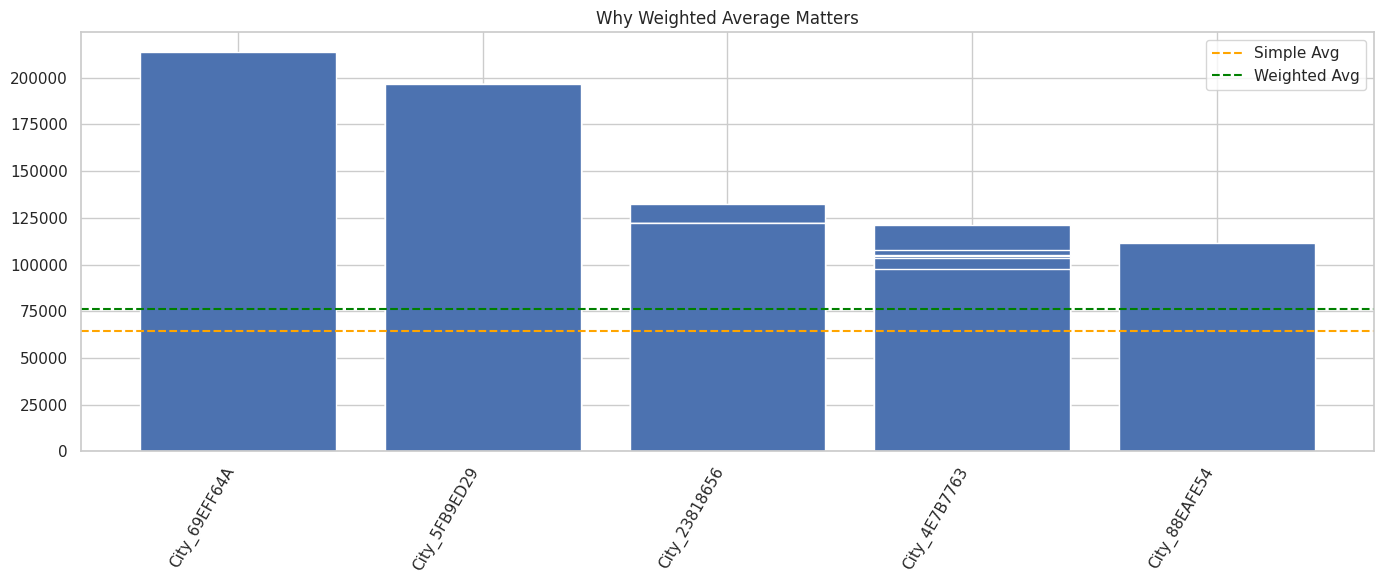

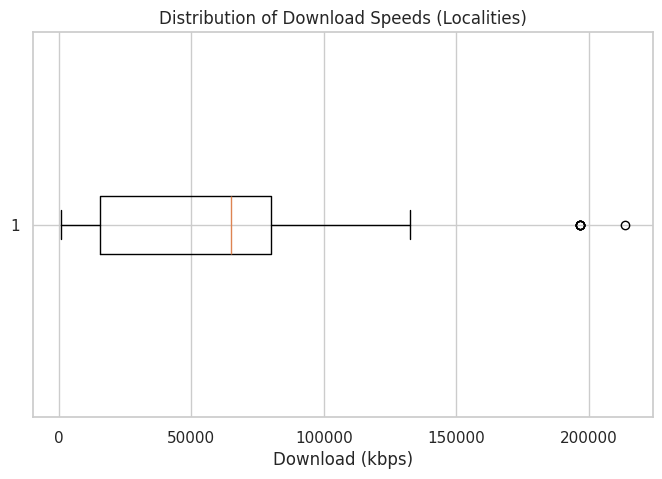

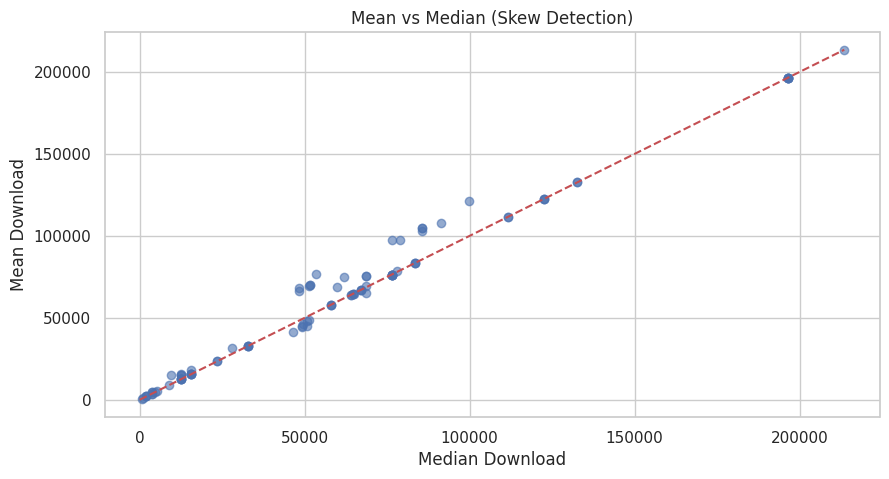

In [18]:
# Sort by download for clarity
plot_df = example_group.sort_values("mean_download_kbps", ascending=False)

# Take top N to avoid clutter
top_n = 20
plot_df_top = plot_df.head(top_n)

# Calculate simple average and weighted average for the mean download speeds in this example group
simple_avg = example_group["mean_download_kbps"].mean()
weighted_avg = (
    (example_group["mean_download_kbps"] * example_group["sample_count"]).sum()
    / example_group["sample_count"].sum()
)

# Plotting the mean download speeds of localities in this group, along with simple and weighted averages
plt.figure(figsize=(14, 6))

plt.bar(plot_df_top["place_name"], plot_df_top["mean_download_kbps"])

plt.axhline(simple_avg, color='orange', linestyle='--', label=f'Simple Avg')
plt.axhline(weighted_avg, color='green', linestyle='--', label=f'Weighted Avg')

plt.xticks(rotation=60, ha='right')
plt.title("Why Weighted Average Matters")
plt.legend()
plt.tight_layout()
plt.show()

# Plotting the distribution of mean download speeds across localities in this group using a boxplot
plt.figure(figsize=(8, 5))

plt.boxplot(example_group["mean_download_kbps"], vert=False)

plt.title("Distribution of Download Speeds (Localities)")
plt.xlabel("Download (kbps)")
plt.grid(True)
plt.show()

# Plotting mean vs median download speeds to visually inspect skewness in this group
plt.figure(figsize=(10, 5))

plt.scatter(
    example_group["median_download_kbps"],
    example_group["mean_download_kbps"],
    alpha=0.6
)

plt.plot(
    [0, example_group["median_download_kbps"].max()],
    [0, example_group["median_download_kbps"].max()],
    'r--'
)

plt.xlabel("Median Download")
plt.ylabel("Mean Download")
plt.title("Mean vs Median (Skew Detection)")
plt.grid(True)
plt.show()

## Step 17 — Save the cleaned outputs

We save **three** files:

1. `weekly_locality_only.csv`  
   Weekly rows with locality only. Good for drill-down.

2. `weekly_country_only.csv`  
   Egypt aggregate only. Good as a benchmark.

3. `weekly_region_carrier_tech.csv`  
   Main Project 6 table after aggregation and filtering.


In [19]:
output_dir = Path("./Processed_Data")
output_dir.mkdir(parents=True, exist_ok=True)

weekly_locality_path = output_dir / "weekly_locality_only.csv"
weekly_country_path = output_dir / "weekly_country_only.csv"
weekly_region_path = output_dir / "weekly_region_carrier_tech.csv"

weekly_locality_df.to_csv(weekly_locality_path, index=False)
weekly_country_df.to_csv(weekly_country_path, index=False)
final_df.to_csv(weekly_region_path, index=False)

print("Saved:")
print("-", weekly_locality_path)
print("-", weekly_country_path)
print("-", weekly_region_path)


Saved:
- Processed_Data/weekly_locality_only.csv
- Processed_Data/weekly_country_only.csv
- Processed_Data/weekly_region_carrier_tech.csv


## Step 18 — Final summary

At this point, the spreadsheet has been cleaned in the right order:

### What we did
- removed **daily** rows
- kept **weekly** rows only
- kept **locality** rows for the main workflow
- separated **country** rows as benchmark-only rows
- checked repeated locality rows and removed exact duplicates if present
- aggregated locality rows into a clean **region × carrier × technology × week** table
- used sample-count weighting for mean KPIs
- used a documented weighted-median proxy for median KPIs
- applied the final **sample_count_total >= 30** threshold
- added helper columns for **mean vs median** analysis

### What comes next
In the next notebook section, we can start the actual anomaly analysis:
- cross-sectional comparisons
- week-over-week change analysis
- region ranking
- technology comparison
- anomaly logging
